In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Dataset: Fashion MNIST

Vi använder Fashion MNIST-datasetet som innehåller 28x28 pixlar gråskalebilder av klädesplagg.

Datan delas upp i träningsdata och testdata:

- Träningsdata används för att lära modellen
- Testdata används för att utvärdera modellen efter träning

In [2]:
# Laddar in Fashion MNIST-datasetet från Keras
fashion_mnist = keras.datasets.fashion_mnist

# Delar upp datan i träningsdata och testdata
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

## Datans struktur

Undersöker datans form för att förstå hur många bilder vi har och hur de är strukturerade.

Varje bild är 28x28 pixlar och lagras som en matris med siffror.

In [3]:
# Skriver ut form (shape) på tränings- och testdata för att förstå datans storlek
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)

print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


## Klassnamn

Eftersom labels i datan är siffror (0–9) använder vi en lista med klassnamn för att göra resultaten mer begripliga.

In [4]:
# Lista med klassnamn som motsvarar siffrorna (0–9) i datasetet
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

for i, name in enumerate(class_names):
    print(i, name)

0 T-shirt/top
1 Trouser
2 Pullover
3 Dress
4 Coat
5 Sandal
6 Shirt
7 Sneaker
8 Bag
9 Ankle boot


## Visualisering av en bild

Visar en enskild bild från datasetet för att förstå hur datan ser ut och hur den kopplas till rätt klass.

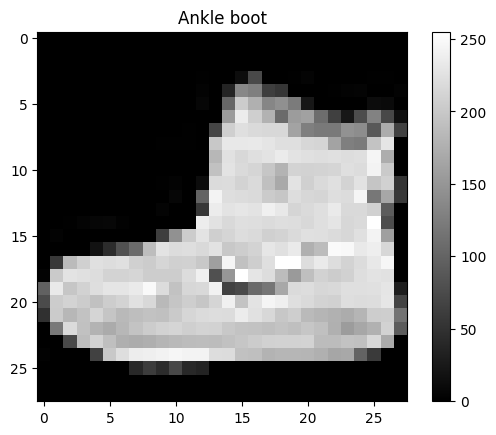

In [5]:
# Visar första bilden i träningsdatan
plt.imshow(X_train[0], cmap='gray')

# Lägger till titel med rätt klassnamn för bilden
plt.title(class_names[y_train[0]])

# Visar färgskalan (pixelvärden)
plt.colorbar()
plt.show()

## Flera exempelbilder

Visar flera bilder samtidigt för att få en bättre känsla för variationen i datasetet och hur olika klasser ser ut.

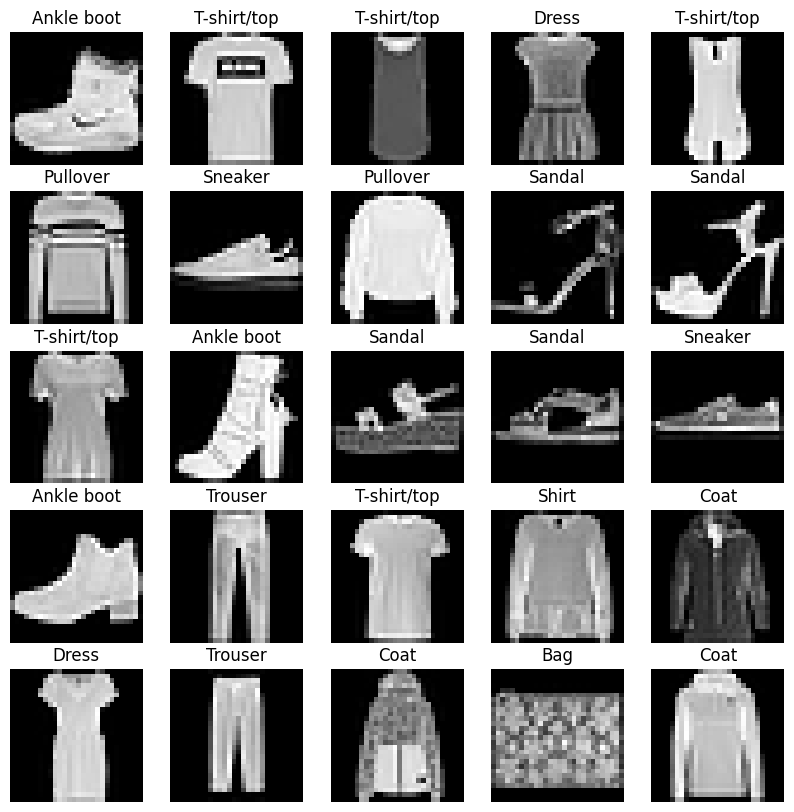

In [6]:
# Visar de första 25 bilderna i träningsdatan i ett 5x5 rutnät,
# tillsammans med respektive klassnamn för att enkelt kunna koppla bild till kategori
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

## Klassfördelning

Räknar antal bilder per klass för att se om datasetet är balanserat.

Ett balanserat dataset är viktigt eftersom modellen då tränas jämnt på alla klasser.

In [7]:
# Räknar hur många bilder som finns i varje klass i träningsdatan
unique, counts = np.unique(y_train, return_counts=True)

# Skriver ut antal bilder per klass för att kontrollera datans fördelning
for label, count in zip(unique, counts):
    print(class_names[label], ':', count)

T-shirt/top : 6000
Trouser : 6000
Pullover : 6000
Dress : 6000
Coat : 6000
Sandal : 6000
Shirt : 6000
Sneaker : 6000
Bag : 6000
Ankle boot : 6000


## X

In [8]:
# Skapa valideringsset

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (48000, 28, 28)
X_val: (12000, 28, 28)
y_train: (48000,)
y_val: (12000,)


In [9]:
# Lägga till kanal-dimension till X_train

X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train shape efter kanal-dimension:", X_train.shape)
print("X_val shape efter kanal-dimension:", X_val.shape)
print("X_test shape efter kanal-dimension:", X_test.shape)

X_train shape efter kanal-dimension: (48000, 28, 28, 1)
X_val shape efter kanal-dimension: (12000, 28, 28, 1)
X_test shape efter kanal-dimension: (10000, 28, 28, 1)


## X

In [10]:
# Normalisera

X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0

X_test_norm = X_test.astype("float32") / 255.0

print("X_train min/max:", X_train.min(), X_train.max())
print("X_val min/max:", X_val.min(), X_val.max())
print("X_test min/max:", X_test_norm.min(), X_test_norm.max())
print("X_train shape:", X_train.shape)

X_train min/max: 0.0 1.0
X_val min/max: 0.0 1.0
X_test min/max: 0.0 1.0
X_train shape: (48000, 28, 28, 1)


## X

In [11]:
# Basmodell

baseline_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])


## X

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8485 - loss: 0.4248 - val_accuracy: 0.8791 - val_loss: 0.3357
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8974 - loss: 0.2867 - val_accuracy: 0.8955 - val_loss: 0.2934
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9131 - loss: 0.2390 - val_accuracy: 0.9007 - val_loss: 0.2758
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9269 - loss: 0.2035 - val_accuracy: 0.9069 - val_loss: 0.2660
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9369 - loss: 0.1742 - val_accuracy: 0.9073 - val_loss: 0.2663
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9470 - loss: 0.1485 - val_accuracy: 0.9080 - val_loss: 0.2756
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9559 - loss: 0.1257 - val_accuracy: 0.9089 - val_loss: 0.2842

Resultat för Basmodell:
Antal epoker:        7
Train accuracy:      0.9559
Train loss:   

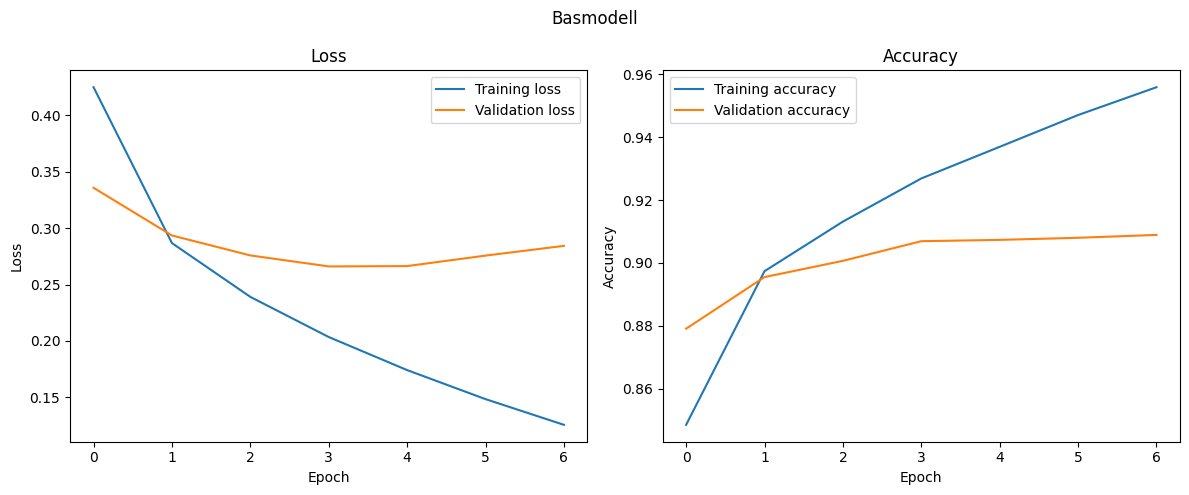

     name  train_accuracy  train_loss  validation_accuracy  validation_loss  epochs_trained  training_time
Basmodell        0.955896    0.125665             0.908917         0.284237               7      28.161298


In [12]:
# Compilerar och tränar basmodellen

from utils import model_compile_and_fit
from utils import plot_history

results = []

h_bas, r_bas = model_compile_and_fit(baseline_model, X_train, y_train, X_val, y_val, name="Basmodell")
results.extend([r_bas])

print(pd.DataFrame(results).to_string(index=False))

## X

In [ ]:
# Förbättrad modell med ett till Conv2D-block

improved_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu",),
    layers.Dense(10, activation="softmax")
])

In [ ]:
# Compilerar och tränar förbättrad modell

h_imp, r_imp = model_compile_and_fit(improved_model, X_train, y_train, X_val, y_val, name="Förbättrad modell")
results.extend([r_imp])

print(pd.DataFrame(results).to_string(index=False))

In [ ]:
# Experiment med SGD och RMSprop optimerare

h_sgd, r_sgd = model_compile_and_fit(improved_model, X_train, y_train, X_val, y_val, name="Förbättrad modell med SGD", optimizer="sgd")
h_rms, r_rms = model_compile_and_fit(improved_model, X_train, y_train, X_val, y_val, name="Förbättrad modell med RMSprop", optimizer="rmsprop")
results.extend([r_sgd, r_rms])

print(pd.DataFrame(results).to_string(index=False))

In [ ]:
# Experiment med SGD och olika inlärningshastigheter

h_low, r_low = model_compile_and_fit(improved_model, X_train, y_train, X_val, y_val, name="Förbättrad modell med SGD och låg inlärningshastighet", optimizer="sgd", learning_rate=0.0001)
h_high, r_high = model_compile_and_fit(improved_model, X_train, y_train, X_val, y_val, name="Förbättrad modell med SGD och hög inlärningshastighet", optimizer="sgd", learning_rate=0.01)
results.extend([r_low, r_high])

print(pd.DataFrame(results).to_string(index=False))

In [ ]:
# Experiment med Adam och olika inlärningshastigheter

h_low, r_low = model_compile_and_fit(improved_model, X_train, y_train, X_val, y_val, name="Förbättrad modell med Adam och låg inlärningshastighet", optimizer="adam", learning_rate=0.0001)
h_high, r_high = model_compile_and_fit(improved_model, X_train, y_train, X_val, y_val, name="Förbättrad modell med Adam och hög inlärningshastighet", optimizer="adam", learning_rate=0.01)
results.extend([r_low, r_high])

print(pd.DataFrame(results).to_string(index=False))

In [ ]:
# Experiment med Adam och step decay inlärningsschema

def step_decay(epoch):
    """
    Enkel step decay-funktion som halverar inlärningshastigheten var 10:e epoch.
    """
    return 0.001 * (0.5 ** (epoch // 10))
step_cb = LearningRateScheduler(step_decay)

h_step, r_step = model_compile_and_fit(improved_model, X_train, y_train, X_val, y_val, name="Förbättrad modell med Adam och step decay", callbacks=[step_cb])
results.append(r_step)

# results = [r for r in results if isinstance(r, dict)]

print(pd.DataFrame(results).to_string(index=False))

In [ ]:
# Experiment med Adam och cosine decay inlärningsschema

def cosine_decay(epoch, total_epochs=20):
    """
    Enkel cosine annealing funktion som varierar inlärningshastigheten mellan 0.001 och 0 över total_epochs epoker.
    """
    return 0.001 * 0.5 * (1 + np.cos(np.pi * epoch / total_epochs))
cos_cb = LearningRateScheduler(cosine_decay)

h_cos, r_cos = model_compile_and_fit(improved_model, X_train, y_train, X_val, y_val, name="Förbättrad modell med Adam och cosine decay", callbacks=[cos_cb])
results.append(r_cos)

print(pd.DataFrame(results).to_string(index=False))

In [ ]:
# Experiment med Adam och plateau inlärningsschema

plateau_cb = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1) # Halverar inlärningshastigheten om valideringsförlusten inte förbättras på 3 epoker

h_pla, r_pla = model_compile_and_fit(improved_model, X_train, y_train, X_val, y_val, name="Förbättrad modell med Adam och plateau", callbacks=[plateau_cb])
results.append(r_pla)

print(pd.DataFrame(results).to_string(index=False))